In [22]:
RAW_PATH = "/Users/niloofarfalahi/Desktop/GitHub/telco-churn-analytics/data/raw/telco_churn.csv"

df_raw = pd.read_csv(RAW_PATH)

df = df_raw.copy()

# Fix TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])  # drops ~11 rows

# Drop identifier
df = df.drop(columns=["customerID"])

# Encode target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Encode binary yes/no columns
yes_no_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for c in yes_no_cols:
    df[c] = df[c].map({"Yes": 1, "No": 0})

# Encode gender
df["gender"] = df["gender"].map({"Female": 0, "Male": 1})

df.shape, df.dtypes.head()

((7032, 20),
 gender           int64
 SeniorCitizen    int64
 Partner          int64
 Dependents       int64
 tenure           int64
 dtype: object)

In [24]:
target = "Churn"
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape, y_train.mean(), y_test.mean()

((5625, 19),
 (1407, 19),
 np.float64(0.2657777777777778),
 np.float64(0.2658137882018479))

In [27]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

binary_cols = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

categorical_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("bin", "passthrough", binary_cols),
    ],
    remainder="drop"
)

In [28]:
clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

clf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [29]:
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

Confusion Matrix:
 [[918 115]
 [160 214]]
ROC-AUC: 0.8360714082341553


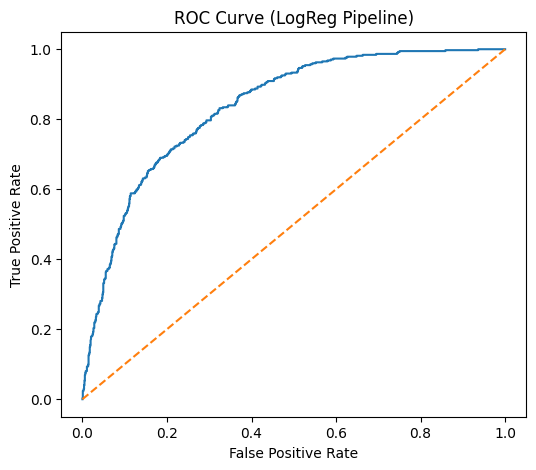

In [30]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve (LogReg Pipeline)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [31]:
ohe = clf.named_steps["preprocess"].named_transformers_["cat"]
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)

all_features = np.concatenate([numeric_cols, ohe_feature_names, binary_cols])

coefs = clf.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({"Feature": all_features, "Coefficient": coefs})
coef_df["AbsCoeff"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoeff", ascending=False).drop(columns=["AbsCoeff"])

coef_df.head(20)

,Feature,Coefficient
0,tenure,-1.355817
20,Contract_Two year,-1.351225
5,InternetService_Fiber optic,1.121685
19,Contract_One year,-0.743489
2,TotalCharges,0.641811
28,PhoneService,-0.522947
1,MonthlyCharges,-0.445174
22,PaymentMethod_Electronic check,0.386286
16,StreamingTV_Yes,0.374880
8,OnlineSecurity_Yes,-0.370820


In [32]:
scores = X_test.copy()
scores["Churn_Prob"] = y_proba
scores["Actual_Churn"] = y_test.values

scores.sort_values("Churn_Prob", ascending=False).head(10)[["Churn_Prob", "Actual_Churn"]]

,Churn_Prob,Actual_Churn
3380,0.847587,1
3159,0.845930,0
2631,0.826006,1
4585,0.823154,1
3727,0.816744,1
2797,0.816017,1
582,0.815395,1
933,0.810974,1
6240,0.792630,1
2516,0.792193,1


In [33]:
import joblib

joblib.dump(clf, "../models/logreg_pipeline.joblib")
scores.to_csv("../data/processed/churn_scores_test_pipeline.csv", index=False)
coef_df.to_csv("../data/processed/logreg_coefficients_pipeline.csv", index=False)

In [36]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

metrics = pd.DataFrame([{
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "test_size": len(y_test)
}])

metrics


,accuracy,precision,recall,f1,roc_auc,test_size
0,0.804549,0.650456,0.572193,0.608819,0.836071,1407
